In [1]:
try:
    import tensorflow_datasets as tfds 
except:
    !pip install tfds-nightly
    import tfds

In [2]:
from pathlib import Path
from src.flow_models.config import Config
from src.flow_models.trainer_gen import GenerationTrainer
import argparse
import sys

import matplotlib.pyplot as plt

from jax import config
from jax import nn
import jax.numpy as jnp
import jax.random as jr

import jax_dataloader as jdl
config.update('jax_cuda_visible_devices', '1')

class Args(argparse.Namespace):
  data_path = None
  model_type = 'ct'
  input_shape = None
  output_shape = None
  latent_shape = None
  recon_weight = 0.0
  reg_weight = 0.0
  crn_type = None
  network_type = None
  hidden_dims = None
  recon_loss_type = 'cross_entropy'
  encoder_model_type = 'identity' # 'mlp', 'mlp_normal', 'resnet', 'resnet_normal', 'identity', 'linear'
  decoder_model_type = 'identity' # 'mlp', 'resnet', 'identity'
  decoder_type = 'linear'
  noise_schedule = 'network' # 'constant', 'linear', 'cosine', 'exponential', 'cauchy', 'laplace', 'logistic', 'quadratic', 'polynomial', 'network'
  noise_schedule_learnable = True

args = Args()
key = jr.PRNGKey(137)

In [3]:
# Construct a tf.data.Dataset
test_ds = tfds.load('mnist', split='test', as_supervised=True)
train_ds = tfds.load('mnist', split='train', as_supervised=True)

jds = jdl.DataLoader(train_ds, 'tensorflow', batch_size=len(train_ds), shuffle=True)
x_train, y_train = next(iter(jds))

mean = x_train.mean(axis=(0, 1, 2))
std = x_train.std(axis=(0, 1, 2))
x_train = jnp.asarray((x_train - mean) / std)
y_train = nn.one_hot(y_train, 10)

print(x_train.shape, y_train.shape)

jds = jdl.DataLoader(test_ds, 'tensorflow', batch_size=len(test_ds), shuffle=True)

x_test, y_test = next(iter(jds))

x_test = jnp.asarray((x_test - mean) / std)
y_test = nn.one_hot(y_test, 10)
print(x_test.shape, y_test.shape)

(60000, 28, 28, 1) (60000, 10)
(10000, 28, 28, 1) (10000, 10)


In [4]:
config_file = 'examples/mnist/config.yaml'
config_path = Path(config_file)
loaded_config = Config.load_yaml(config_file)
base_config = Config.merge_with_defaults(loaded_config)

x_sample = x_train[0:1]
y_sample = y_train[0:1]

def make_trainer(args, seed):
    config = base_config.override_from_args(args, args.model_type, False)

    trainer = GenerationTrainer(
        config=config,
        learning_rate=5e-3,
        optimizer_name='adamw',
        seed=seed,
        unconditional=False,
        warmup_steps=0,
        model_type=args.model_type
    )

    trainer.initialize(x_sample, y_sample)

    return trainer

def run_experiment(key, args, x_train, y_train, x_test, y_test, num_epochs=50):
    fig, axes = plt.subplots(2, 5, figsize=(16, 8), sharex=True, sharey=True)
    for i, ns in enumerate(['constant', 'linear', 'exponential', 'logistic', 'network']):
        for j, learn in enumerate([True, False]):
            args.noise_schedule = ns
            args.noise_schedule_learnable = learn

            key, _key = jr.split(key)

            trainer = make_trainer(args, _key[0].item())

            history = trainer.train(
                x_data=x_train,
                y_data=y_train,
                num_epochs=num_epochs,
                batch_size=1024,
                validation_data=(x_test, y_test),
                dropout_epochs=0
            )

            key, _key = jr.split(key)
            y_gen = trainer.conditional_generate(x_test, num_steps=200, prng_key=key)
            acc = jnp.mean(y_test.argmax(-1) == y_gen.argmax(-1))

            axes[j, i].plot(jnp.arange(1, num_epochs + 1), history['train_losses'], label='train')
            axes[j, i].plot(jnp.arange(1, num_epochs + 1), history['val_losses'], label='val')

            axes[j, i].set_title(f'NS={ns}, LRN={learn}, ACC={acc:.3f}', fontsize=10)
        
        axes[-1, i].set_xlabel('Epoch')
        axes[0, 0].legend(title='loss')

    fig.tight_layout()
    return key

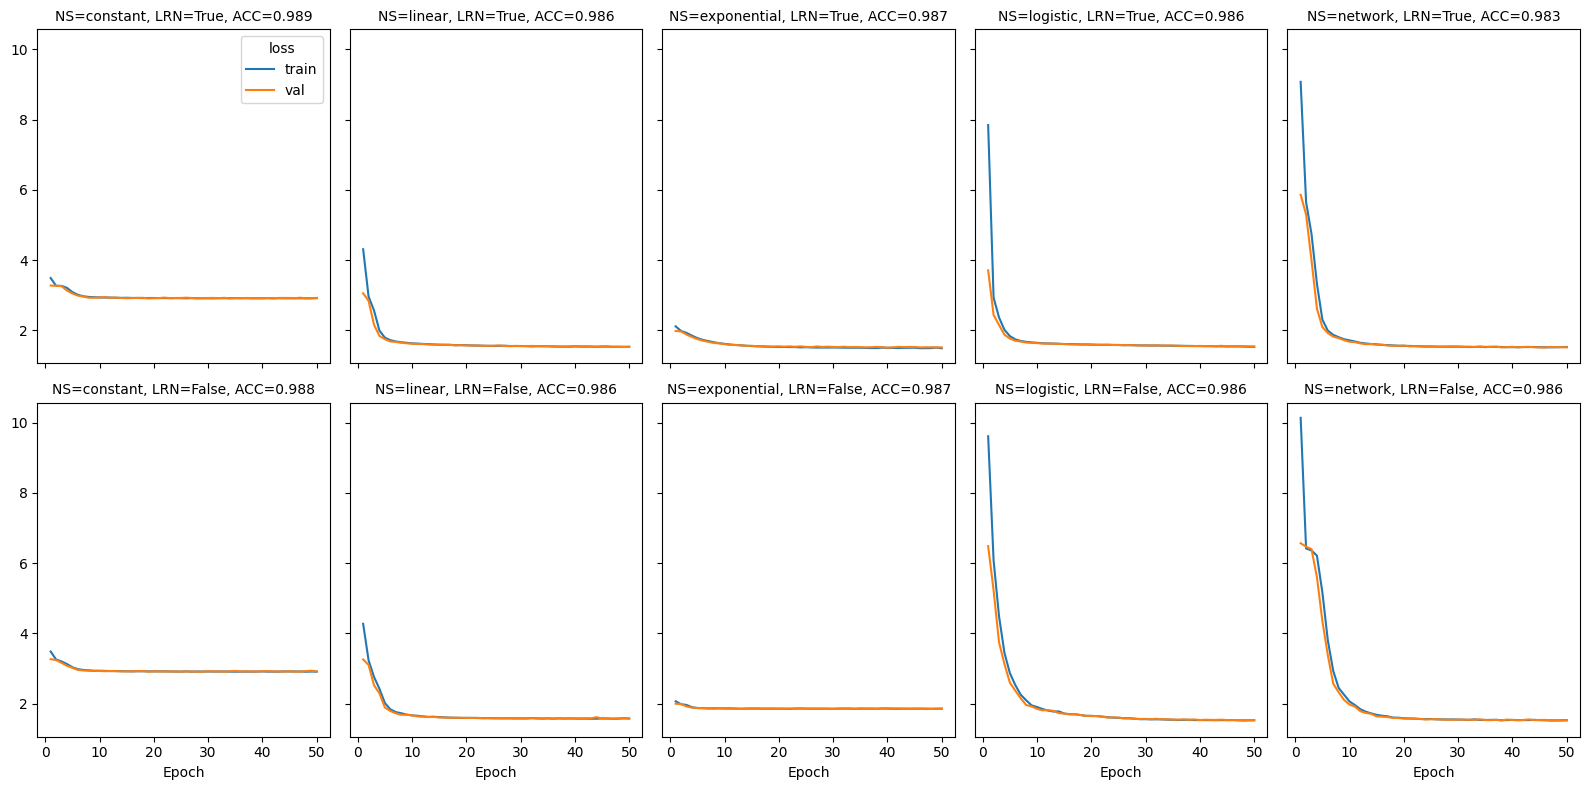

In [5]:
key = run_experiment(key, args, x_train, y_train, x_test, y_test)

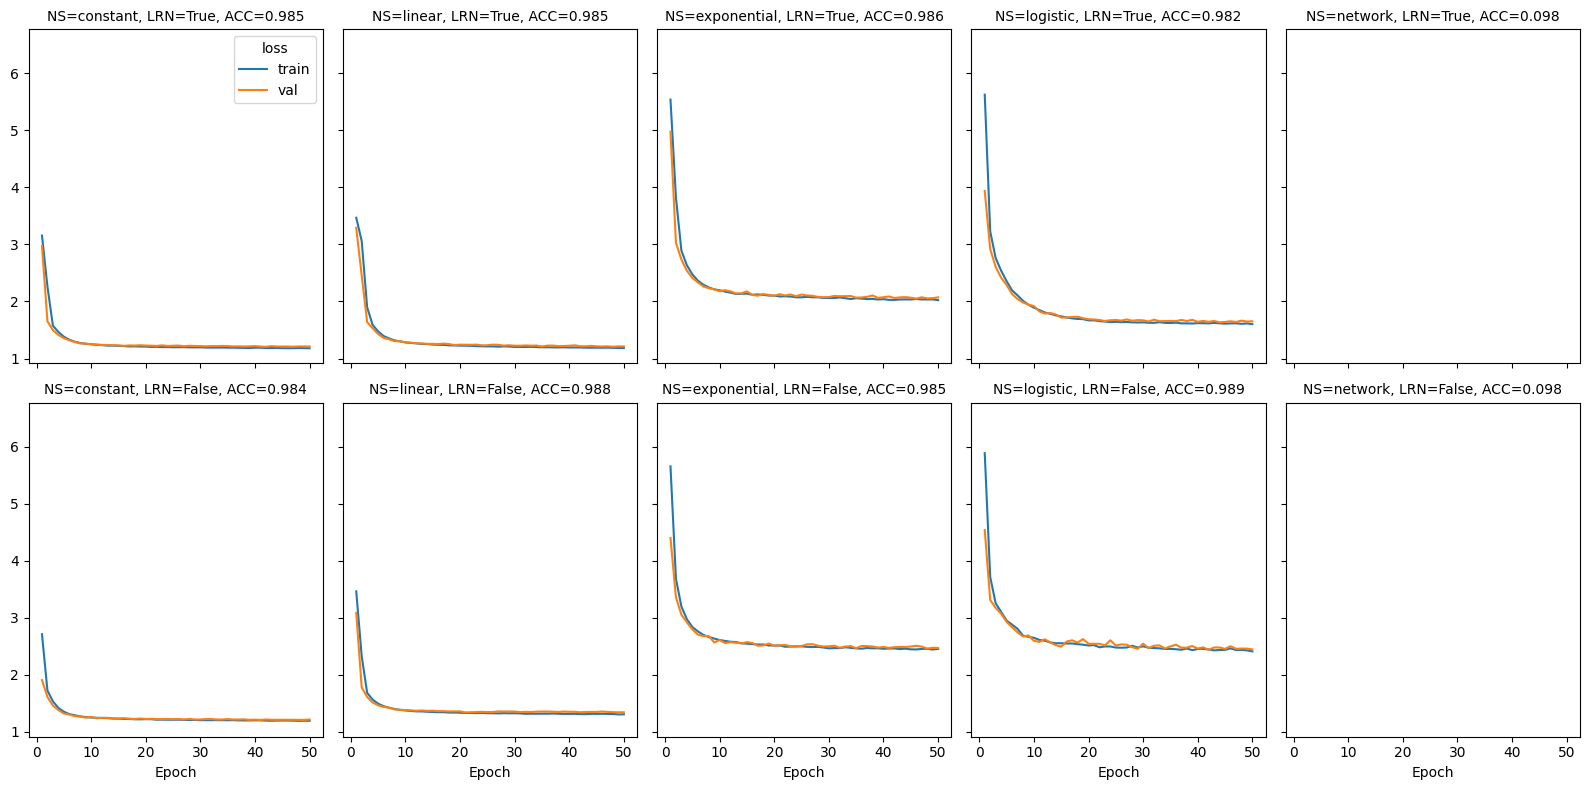

In [6]:
args.model_type = 'flow_matching'
args.recon_weight = 1.0
args.vae_weight = 0.0
key = run_experiment(key, args, x_train, y_train, x_test, y_test)